# Reflection and transmission at an Interface (fresnel equations)

## 1. Physical model

A monochromatic electromagnetic wave is one that has a single wavelength and therefore a constant frequency. It is perceived by the human eye as a single spectral color.

We consider a monochromatic plane electromagnetic wave incident on the interface between two dielectric media with refractive indices $n_1$ and $n_2$ .
The wave is partially reflected and partially transmitted. The behaviour depends on:

- Angle of incidence $\theta_i$
- Polarization (s or p)
- Refractive indices ($n_1$, $n_2$)

We assume a monochromatic plane electromagnetic field of angular frequency $\omega$. The time dependence is harmonic and can be written as:

$E(r,t) = Re \{ E(r) e^{-i\omega t} \}$

This assumption allows us to treat the problem in the frequency domain and apply boundary conditions to the spatial amplitudes of the fields.

## 2. Snell's Law

The angle of transmission is determined by Snell's law:
 
$n_1 \sin{\theta_i} = n_2 \sin{\theta_t}$

The relation follows from the continuity of the tangential component of the wavevector at the interface.

## 3. Boundary conditions at the interface

Maxwell's equations impose continuity conditions at the interface between two dielectric media:

- The tangencial component of the electric field is continuous.
- The tangencial component of the magnetic field is continuous.

The boundary conditions determine the reflected and transmitted amplitudes and lead to the Fresnel coefficients.

## 4. Polarization states
Two polarization states must be considered:

- s-polarization : The electric field is perpendicular to the plane of incidence
- p-polarization : The electric field lies in the plane of incidence.

## 5. Fresnel reflection coefficients 
From Maxwell's boundary conditions, the amplitude reflection coefficients are:

### s-polarization (perpendicular)
$r_s = \dfrac{n_1\cos\theta_i - n_2\cos\theta_t}{n_1\cos\theta_i + n_2\cos\theta_t}$

### p-polarization (parallel)

$r_p = \dfrac{n_2\cos\theta_i - n_1\cos\theta_t}{n_2\cos\theta_i + n_1\cos\theta_t}$

## 6. Reflectance and Tramittance
The physically observable quantity is the reflectance:

$ R = |{r}|^2$

which represents the fraction of the incident intensity at the interface.

The transmittance $T$ is defined as the fraction of the incident intensity that is transmitted into the second medium.

For lossless dielectric media, energy conservation requires .

$R+T=1$

However, this applies to simple cases; the transmittance is given by the transmission coefficients that can be obtained through Maxwell's boundary equations.

## 7. Fresnel transmission coefficients 

### s-polarization (perpendicular)

$t_s = \dfrac{2n_1\cos\theta_i}{n_1\cos\theta_i + n_2\cos\theta_t}$

### p-polarization (parallel)

$t_ p= \dfrac{2n_1\cos\theta_i}{n_2\cos\theta_i + n_1\cos\theta_t}$

Analogous to refraction, the observable physical quantity transmitted is transmittance:

$T = \dfrac{n_2\cos\theta_t}{n_1\cos\theta_i} |t|^2$

## 8. Brewster Angle

For p-polarization there exists and exact angle $\theta_B$ at which the reflection vanishes:

$\tan\theta_B = \dfrac{n_2}{n_1}$

At this angle, the reflected wave for p-polarization disappears. The effect arises from the vector nature of electromagnetic waves.

### Computational approach
In this part of the project, the effect of polarized light and the angle of incidence on the reflection and transmission of light is analyzed by studying its behavior. At the same time, we verify energy conservation by analyzing the progress of the transmittance and reflectance fractions as a function of the angle of incidence.

We apply the numerically implemented fresnel equations using Python. 

This approach follows the classical treatment presented in Hecht, *Optics*, and provides a computational perspective on fundamental reflection and transmission.

## Definition of functions
To facilitate the use of Fresnel equations, we defined several functions to perform the analytical operations of the reflection and transmission coefficients and the transmission angle based on the Snell formula.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import os
folder_path = "../figures/week 2"
os.makedirs(folder_path, exist_ok=True)

In [4]:
def snell(n1, n2, theta_i):
    return np.arcsin((n1/n2)*np.sin(theta_i))

def fresnel_rs(n1, n2, theta_i):
    theta_t = snell(n1, n2, theta_i)
    numerator = n1*np.cos(theta_i) - n2*np.cos(theta_t)
    denominator = n1*np.cos(theta_i) + n2*np.cos(theta_t)
    return numerator/denominator

def fresnel_rp(n1, n2, theta_i):
    theta_t = snell(n1, n2, theta_i)
    numerator = n2*np.cos(theta_i) - n1*np.cos(theta_t)
    denominator = n2*np.cos(theta_i) + n1*np.cos(theta_t)
    return numerator/denominator

def fresnel_ts(n1, n2, theta_i):
    theta_t = snell(n1, n2, theta_i)
    numerator = 2 * n1 *np.cos(theta_i)
    denominator = n1*np.cos(theta_i) + n2*np.cos(theta_t)
    return numerator/denominator


def fresnel_tp(n1, n2, theta_i):
    theta_t = snell(n1, n2, theta_i)
    numerator = 2 * n1 *np.cos(theta_i)
    denominator = n2*np.cos(theta_i) + n1*np.cos(theta_t)
    return numerator/denominator

## Physical parameters
The dielectric media for this study are air, $n_1=1$, and glass, $n_2=1.5$. The range of incidence angles covers the entire spectrum of possible values.

In [5]:
n1 = 1.0  # air
n2 = 1.5  # glass

theta_i = np.linspace(0, np.radians(80), 1000)

## Numerical simulation

### Reflectance and Tramittance

In [6]:
r_s = fresnel_rs(n1, n2, theta_i)
r_p = fresnel_rp(n1, n2, theta_i)

R_s = np.abs(r_s)**2
R_p = np.abs(r_p)**2

t_s = fresnel_ts(n1, n2, theta_i)
t_p = fresnel_tp(n1, n2, theta_i)

theta_t = snell(n1, n2, theta_i)

T_s = (n2 * np.cos(theta_t) / (n1 * np.cos(theta_i))) * np.abs(t_s)**2
T_p = (n2 * np.cos(theta_t) / (n1 * np.cos(theta_i))) * np.abs(t_p)**2

### Brewster angle

In [7]:
theta_B = np.arctan(n2/n1)
print(np.degrees(theta_B))

56.309932474020215


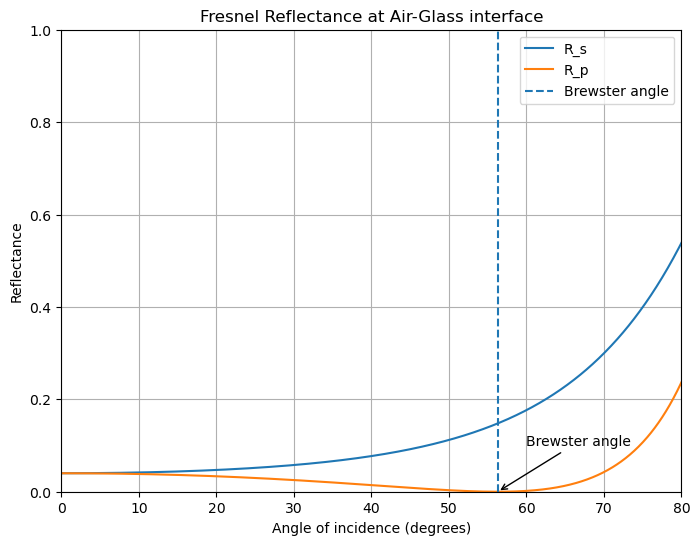

In [8]:
plt.figure(figsize=(8,6))

plt.plot(np.degrees(theta_i), R_s, label="R_s")
plt.plot(np.degrees(theta_i), R_p, label="R_p")

plt.axvline(np.degrees(theta_B), linestyle="--", label="Brewster angle")

plt.xlabel("Angle of incidence (degrees)")
plt.ylabel("Reflectance")
plt.ylim(0,1)
plt.xlim(0,80)
plt.annotate("Brewster angle", xy=(np.degrees(theta_B),0), xytext=(60,0.1), arrowprops=dict(arrowstyle="->"))
plt.title("Fresnel Reflectance at Air-Glass interface")
plt.legend()
plt.grid()
plt.savefig(f"{folder_path}/Fresnel_Reflectance.png", dpi=300)
plt.show()

In [9]:
print(np.max(np.abs(R_s + T_s -1)))
print(np.max(np.abs(R_p + T_p -1)))

4.440892098500626e-16
5.551115123125783e-16


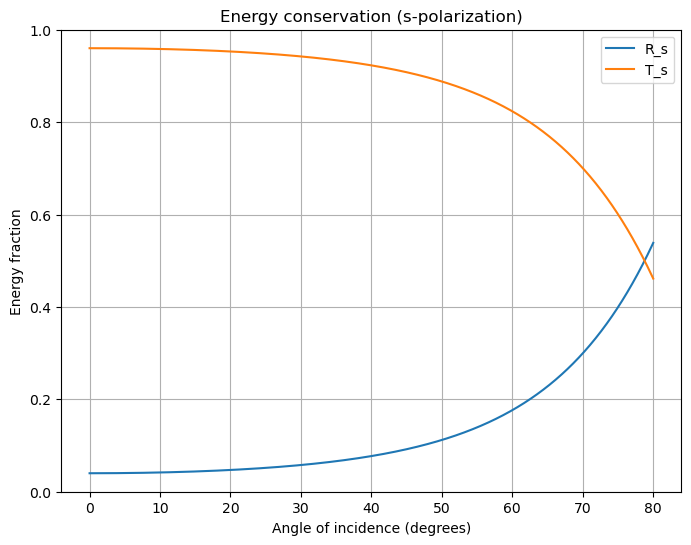

In [10]:
plt.figure(figsize=(8,6))

plt.plot(np.degrees(theta_i), R_s, label="R_s")
plt.plot(np.degrees(theta_i), T_s, label="T_s")


plt.xlabel("Angle of incidence (degrees)")
plt.ylabel("Energy fraction")
plt.ylim(0,1)
plt.title("Energy conservation (s-polarization)")
plt.legend()
plt.grid()
plt.savefig(f"{folder_path}/EnergyConservation_s.png", dpi=300)
plt.show()

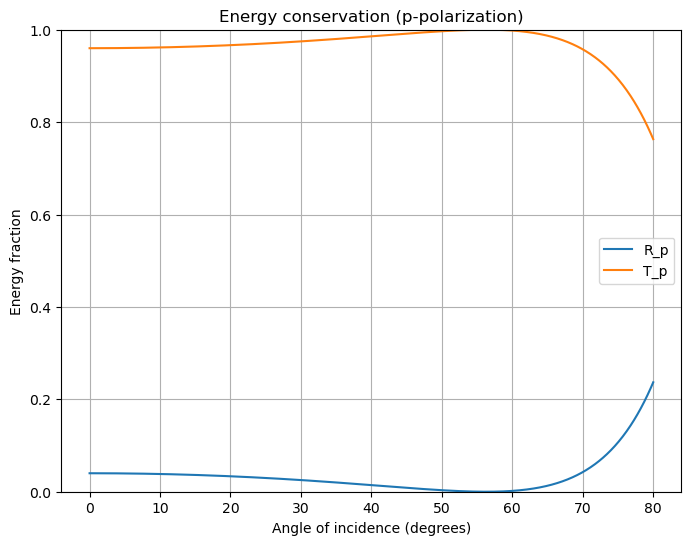

In [11]:
plt.figure(figsize=(8,6))

plt.plot(np.degrees(theta_i), R_p, label="R_p")
plt.plot(np.degrees(theta_i), T_p, label="T_p")


plt.xlabel("Angle of incidence (degrees)")
plt.ylabel("Energy fraction")
plt.ylim(0,1)
plt.title("Energy conservation (p-polarization)")
plt.legend()
plt.grid()
plt.savefig(f"{folder_path}/EnergyConservation_p.png", dpi=300)
plt.show()

With respect to the perpendicular factor of reflectance, we observe an increase as the angle of incidence increases. Meanwhile, the parallel factor decreases until it reaches the Brewster angle and then increases.

In additions to amplitude changes, the reflection process also involves phase shifts that depend on polarization and incidence angle.

## Conclusions and discussion

The results show that reflectance strongly depends on polarization. While s-polarized is always partially reflected, p-polarized light exhibits a zero-reflection condition at Brewster's angle.

This polarization-dependent behaviour arises directly from Maxwell's boundary conditions and illustrate the vector nature of electromagnetic waves.

The computed reflectance and transmittance satisfy the relation:

$R + T = 1$

within numericla presicion ($10^{-15}$). This confirms energy conservation in lossless dielectric media and validates the correctness of the numerical implementation.

The agreement between analytical theory and computational simulation demonstrates the consistency between classical electromagnetic theory and computational modeling.

Altough total internal reflection does not occur in the present configuration ($n_1 < n_2$), it would arise if light propagated from a higher to a lower refractive index medium ($n1 > n2$). In that case, fon incidence angles above the critical angle 

$\sin(\theta_c) =\dfrac{n_2}{n_1}$

the transmitted wave becomes evanescent and reflectance becomes unity. This phenomenal plays a fundamental role in optical fibers and waveguides.

We have successfully modeled a single interference using Maxwell's boundary conditions. However, real-world opticcal coatings involve thin films with two or more boundaries. In the next chapter, we will expand this vectorial model to account for the spatial dimension $z$, introducing multiple-beam and phase acccumulation inside a Fabry-Pérot cavity.
